# 3D Fractional PDE — Figures for the Paper

This notebook **loads pre-trained model weights** and regenerates the figures
used in the manuscript. It does not perform training — see `3DfPDE_solver.ipynb`
for that.

## Contents

1. **Configuration** — domain, weight paths, and plotting settings.
2. **Imports & setup** — libraries and matplotlib style.
3. **Model architecture** — same network class as the solver (needed to load weights).
4. **Exact solution & helpers** — analytical reference and shared utilities.
5. **Collocation-point study** — comparison across `NX = NY = NT ∈ {5, 10, 20}`.
6. **Time-step study** — varying `NT` with fixed `NX = NY = 5`.
7. **Spatial-grid study** — varying `NX = NY` with fixed `NT = 5`.
8. **Diethelm vs L1 comparison** — line plots at several time snapshots.
9. **Time-window study** — `TMAX = 0.5` vs `TMAX = 1.0`.
10. **Network-size study** — small / medium / large architectures.
11. **3D scatter comparison** — exact, Diethelm, and L1 over full (x, y, t) volume.
12. **Quantitative evaluation** — L2/L∞ errors, runtime curves.

## 1. Configuration

All file paths and tunable parameters live here. Change these — not the cells below.

In [2]:
# ---- Domain ------------------------------------------------------------
XMIN, XMAX = 0.0, 2.0
YMIN, YMAX = 0.0, 2.0
TMIN       = 0.0

# ---- Network architecture (must match the trained models) --------------
NUM_HIDDEN_LAYERS     = 4
NUM_NEURONS_PER_LAYER = 20
ACTIVATION            = 'tanh'
KERNEL_INITIALIZER    = 'glorot_normal'

# ---- Fractional derivative order ---------------------------------------
ALPHA = 0.7

# ---- Reproducibility ---------------------------------------------------
RANDOM_SEED = 42

# ---- Data type ---------------------------------------------------------
DTYPE = 'float32'

# ---- Plot style --------------------------------------------------------
COLORS = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple',
          'tab:brown', 'tab:pink', 'tab:gray', 'tab:olive', 'tab:cyan',
          'gold', 'lightcoral', 'k']
MARKERS    = ['o', 'v', 'x', 's', '+', '^', '1', '2', 'd', '<', '>', '*', 'p']
LINE_WIDTH = [4, 3]   # solid lines, dashed lines

# ---- Evaluation settings -----------------------------------------------
N_EVAL        = 40    # points per dimension for 1-D slice plots
N_EVAL_3D     = 75    # points per dimension for 3-D scatter plots
TIME_SNAPSHOTS = [0.1, 0.3, 0.5]   # time slices shown in every comparison plot
X_SLICE       = 1.0  # fixed x value used for y-slice plots (midpoint of domain)

# ===========================================================================
# WEIGHT FILE PATHS  — update these to point to your saved model directories
# ===========================================================================

BASE = '/Users/joshuadarosa/Desktop/New-3D_Results_modify_4_21_26/Collac_study'   # root folder containing all weight subdirectories

# ---- Section 5: Collocation-point study (NX=NY=NT, Caputo, 30 min) --------
COLLOC_SETS = [
    {'nx': 5,  'ny': 5,  'nt': 5,
     'label': r'$n_x=5,\ n_y=5,\ n_t=5$',
     'weights': f'{BASE}/Caputo_order/time_30_min/n_x_5/n_y_5/n_t_5/WEIGHTS/my_model.tf'},
    {'nx': 10, 'ny': 10, 'nt': 10,
     'label': r'$n_x=10,\ n_y=10,\ n_t=10$',
     'weights': f'{BASE}/Caputo_order/time_30_min/n_x_10/n_y_10/n_t_10/WEIGHTS/my_model.tf'},
    {'nx': 20, 'ny': 20, 'nt': 20,
     'label': r'$n_x=20,\ n_y=20,\ n_t=20$',
     'weights': f'{BASE}/Caputo_order/time_30_min/n_x_20/n_y_20/n_t_20/WEIGHTS/my_model.tf'},
]
TMAX_COLLOC = 0.5

# ---- Section 6: Time-step study (fixed NX=NY=5, varying NT) ---------------
TIME_STEP_SETS = [
    {'nx': 5, 'ny': 5, 'nt': 5,
     'label': r'$n_t=5$',
     'weights': f'{BASE}/Caputo_order/time_30_min/n_x_5/n_y_5/n_t_5/WEIGHTS/my_model.tf'},
    {'nx': 5, 'ny': 5, 'nt': 10,
     'label': r'$n_t=10$',
     'weights': f'{BASE}/Caputo_order/time_30_min/n_x_5/n_y_5/n_t_10/WEIGHTS/my_model.tf'},
    {'nx': 5, 'ny': 5, 'nt': 20,
     'label': r'$n_t=20$',
     'weights': f'{BASE}/Caputo_order/time_30_min/n_x_5/n_y_5/n_t_20/WEIGHTS/my_model.tf'},
    {'nx': 5, 'ny': 5, 'nt': 40,
     'label': r'$n_t=40$',
     'weights': f'{BASE}/Caputo_order/time_30_min/n_x_5/n_y_5/n_t_40/WEIGHTS/my_model.tf'},
]
TMAX_TIME_STEP = 0.5

# ---- Section 7: Spatial-grid study (fixed NT=5, varying NX=NY) ------------
SPATIAL_SETS = [
    {'nx': 5,  'ny': 5,  'nt': 5,
     'label': r'$n_x=5,\ n_y=5$',
     'weights': f'{BASE}/Caputo_order/time_30_min/n_x_5/n_y_5/n_t_5/WEIGHTS/my_model.tf'},
    {'nx': 10, 'ny': 10, 'nt': 5,
     'label': r'$n_x=10,\ n_y=10$',
     'weights': f'{BASE}/Caputo_order/time_30_min/n_x_10/n_y_10/n_t_5/WEIGHTS/my_model.tf'},
    {'nx': 20, 'ny': 20, 'nt': 5,
     'label': r'$n_x=20,\ n_y=20$',
     'weights': f'{BASE}/Caputo_order/time_30_min/n_x_20/n_y_20/n_t_5/WEIGHTS/my_model.tf'},
]
TMAX_SPATIAL = 0.5

# ---- Section 8: Diethelm vs L1 -------------------------------------------
METHOD_COMP_NX  = 5
METHOD_COMP_NY  = 5
METHOD_COMP_NT  = 40
TMAX_METHOD     = 0.5
WEIGHTS_CAPUTO  = f'{BASE}/Caputo_order/time_30_min/n_x_5/n_y_5/n_t_40/WEIGHTS/my_model.tf'
WEIGHTS_L1      = f'{BASE}/L1_order/time_30_min/n_x_5/n_y_5/n_t_40/WEIGHTS/my_model.tf'

# ---- Section 9: Time-window study ----------------------------------------
TMAX_05_WEIGHTS = f'{BASE}/Caputo_order/time_30_min/n_x_5/n_y_5/n_t_40/WEIGHTS/my_model.tf'
TMAX_10_WEIGHTS = f'{BASE}/TMAX_1.0/WEIGHTS/my_model.tf'
TMAX_05         = 0.5
TMAX_10         = 1.0

# ---- Section 10: Network-size study --------------------------------------
NETWORK_SETS = [
    {'layers': 2, 'neurons': 10, 'tmax': 0.5,
     'label': r'$2L,\ 10N$',
     'weights': f'{BASE}/2_10_NN_TMAX_0.5/WEIGHTS/my_model.tf'},
    {'layers': 3, 'neurons': 10, 'tmax': 0.5,
     'label': r'$3L,\ 10N$',
     'weights': f'{BASE}/3_10_NN_TMAX_0.5/WEIGHTS/my_model.tf'},
    {'layers': 4, 'neurons': 20, 'tmax': 0.5,
     'label': r'$4L,\ 20N$',
     'weights': f'{BASE}/Caputo_order/time_30_min/n_x_5/n_y_5/n_t_40/WEIGHTS/my_model.tf'},
    {'layers': 7, 'neurons': 40, 'tmax': 0.5,
     'label': r'$7L,\ 40N$',
     'weights': f'{BASE}/TMAX_0.5_LNN/WEIGHTS/my_model.tf'},
]

# ---- Section 11: 3-D scatter comparison ----------------------------------
WEIGHTS_3D_CAPUTO = WEIGHTS_CAPUTO
WEIGHTS_3D_L1     = WEIGHTS_L1
TMAX_3D           = TMAX_METHOD

# ---- Section 12: Quantitative evaluation ---------------------------------
# Each entry: (label, tmax, nx, ny, nt, runtime_minutes, iterations, weights_path)
EVAL_CASES = [
    ('5×5×5  Caputo 30min',   0.5, 5,  5,  5,  30, None, f'{BASE}/Caputo_order/time_30_min/n_x_5/n_y_5/n_t_5/WEIGHTS/my_model.tf'),
    ('10×10×10 Caputo 30min', 0.5, 10, 10, 10, 30, None, f'{BASE}/Caputo_order/time_30_min/n_x_10/n_y_10/n_t_10/WEIGHTS/my_model.tf'),
    ('5×5×40 Caputo 30min',   0.5, 5,  5,  40, 30, None, f'{BASE}/Caputo_order/time_30_min/n_x_5/n_y_5/n_t_40/WEIGHTS/my_model.tf'),
    ('5×5×40 L1 30min',       0.5, 5,  5,  40, 30, None, f'{BASE}/L1_order/time_30_min/n_x_5/n_y_5/n_t_40/WEIGHTS/my_model.tf'),
]

## 2. Imports and Setup

In [3]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from matplotlib import rc
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import MaxNLocator, FuncFormatter
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from itertools import product
import pandas as pd

# Set default dtype and seed
tf.keras.backend.set_floatx(DTYPE)
tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Matplotlib style (LaTeX fonts)
rc('font', **{'family': 'Times'})
rc('text', usetex=True)

plt.rc('font',   size=17)
plt.rc('axes',   titlesize=20)
plt.rc('axes',   labelsize=20)
plt.rc('xtick',  labelsize=15)
plt.rc('ytick',  labelsize=15)
plt.rc('legend', fontsize=16)
plt.rc('figure', titlesize=20)


def gamma_tf(x):
    """Gamma function for TF tensors (via log-gamma)."""
    return tf.exp(tf.math.lgamma(x))

## 3. Model Architecture

Must match the architecture used during training — otherwise the saved weights will not load.

In [4]:
class PINN_NeuralNet(tf.keras.Model):
    """Fully-connected PINN architecture. Must match the trained model."""

    def __init__(self, lb, ub,
                 output_dim=1,
                 num_hidden_layers=NUM_HIDDEN_LAYERS,
                 num_neurons_per_layer=NUM_NEURONS_PER_LAYER,
                 activation=ACTIVATION,
                 kernel_initializer=KERNEL_INITIALIZER,
                 **kwargs):
        super().__init__(**kwargs)
        self.num_hidden_layers = num_hidden_layers
        self.output_dim        = output_dim
        self.lb = lb
        self.ub = ub

        self.hidden = [
            tf.keras.layers.Dense(
                num_neurons_per_layer,
                activation=tf.keras.activations.get(activation),
                kernel_initializer=kernel_initializer,
            )
            for _ in range(num_hidden_layers)
        ]
        self.out = tf.keras.layers.Dense(output_dim)

    def call(self, X):
        Z = X
        for layer in self.hidden:
            Z = layer(Z)
        return self.out(Z)


def load_model(weights_path, tmax,
               num_layers=NUM_HIDDEN_LAYERS,
               num_neurons=NUM_NEURONS_PER_LAYER):
    """Instantiate a PINN with the given architecture and load pre-trained weights."""
    lb = [XMIN, YMIN, TMIN]
    ub = [XMAX, YMAX, tmax]
    model = PINN_NeuralNet(lb, ub,
                           num_hidden_layers=num_layers,
                           num_neurons_per_layer=num_neurons)
    model.build(input_shape=(None, 3))
    model.load_weights(weights_path)
    return model

## 4. Exact Solution and Shared Helpers

In [5]:
def exact_solution(x, y, t):
    """Analytical reference solution: u = t^2 * [x(2-x) + y(2-y)]."""
    return t ** 2 * (x * (2.0 - x) + y * (2.0 - y))


def eval_slice(model, t_snap, n_eval=N_EVAL, x_fixed=X_SLICE):
    """Evaluate model and exact solution along the y-axis at fixed x and t.

    Returns (yspace, u_pred, u_exact) as numpy arrays.
    """
    yspace = np.linspace(YMIN, YMAX, n_eval)
    xspace = np.full(n_eval, x_fixed)
    tspace = np.full(n_eval, t_snap)
    X_eval = np.stack([xspace, yspace, tspace], axis=1)
    u_pred  = model(X_eval).numpy().flatten()
    u_exact = exact_solution(xspace, yspace, tspace)
    return yspace, u_pred, u_exact


def make_comparison_figure(cases, tmax, title_prefix='', save_as=None):
    """
    Generic 1×3 subplot figure comparing multiple cases at TIME_SNAPSHOTS.

    cases : list of dicts with keys 'model', 'label'
    """
    fig, ax = plt.subplots(1, 3, sharex=False, sharey=False, figsize=(15, 5))
    axs = ax.flat
    sub_cap = ['(a)', '(b)', '(c)']

    for sub_p, t_snap in enumerate(TIME_SNAPSHOTS):
        # Exact solution (plotted once)
        yspace = np.linspace(YMIN, YMAX, N_EVAL)
        xspace = np.full(N_EVAL, X_SLICE)
        tspace = np.full(N_EVAL, t_snap)
        u_ref  = exact_solution(xspace, yspace, tspace)
        axs[sub_p].plot(yspace, u_ref, label=r'$Exact$',
                        lw=LINE_WIDTH[1], color=COLORS[0])

        for i, case in enumerate(cases):
            _, u_pred, _ = eval_slice(case['model'], t_snap)
            axs[sub_p].scatter(yspace, u_pred, label=case['label'],
                               marker=MARKERS[i], color=COLORS[i + 1])

        axs[sub_p].title.set_text(sub_cap[sub_p])
        axs[sub_p].set_xlabel('$y$')
        axs[sub_p].set_xlim((-0.1, 2.1))
        axs[sub_p].locator_params(axis='x', nbins=5)
        if sub_p == 0:
            axs[sub_p].set_ylabel('$u(x, y, t)$')
            axs[sub_p].legend(loc='upper center', borderpad=0.05)

    if save_as:
        plt.savefig(save_as, dpi=300, transparent=False, bbox_inches='tight')
        print(f'Saved: {save_as}')
    plt.show()


def compute_error_metrics(model, tmax, n_eval=20):
    """L2 relative and L-infinity absolute error against the exact solution.

    Evaluates over the full (x, y, t) volume on a coarse uniform grid.
    """
    pts    = list(product(np.linspace(XMIN, XMAX, n_eval),
                          np.linspace(YMIN, YMAX, n_eval),
                          np.linspace(TMIN, tmax,  n_eval)))
    X_eval = tf.convert_to_tensor(pts, dtype=DTYPE)
    X_np   = np.array(pts)

    u_pred_v = model(X_eval).numpy().flatten()
    u_ref_v  = exact_solution(X_np[:, 0], X_np[:, 1], X_np[:, 2])

    l2_rel   = float(np.linalg.norm(u_pred_v - u_ref_v) / np.linalg.norm(u_ref_v))
    linf_abs = float(np.max(np.abs(u_pred_v - u_ref_v)))
    return l2_rel, linf_abs

## 5. Effect of Collocation Points

Compare PINN predictions at `TIME_SNAPSHOTS` for grids where
`NX = NY = NT ∈ {5, 10, 20}`. Weight paths are set in Section 1 under `COLLOC_SETS`.

Saved: planar_colloc_study.png


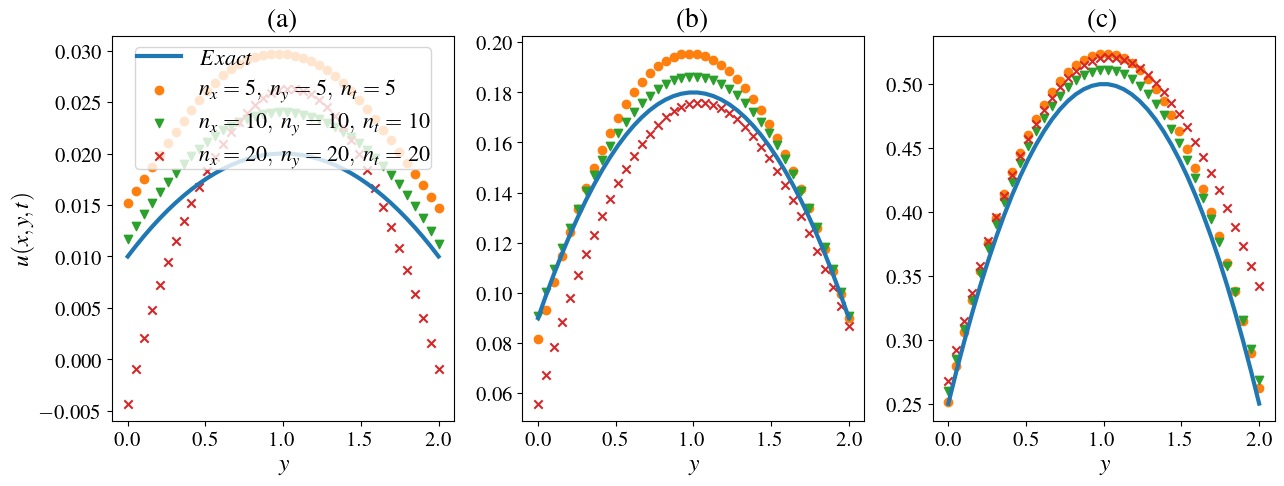

In [6]:
# Load all models for the collocation study
colloc_cases = []
for cfg in COLLOC_SETS:
    m = load_model(cfg['weights'], TMAX_COLLOC)
    colloc_cases.append({'model': m, 'label': cfg['label']})

make_comparison_figure(colloc_cases, TMAX_COLLOC,
                       save_as='planar_colloc_study.png')

## 6. Effect of Time-Step Density

Fixed `NX = NY = 5`, varying `NT ∈ {5, 10, 20, 40}`.
Weight paths are set in Section 1 under `TIME_STEP_SETS`.

Saved: time_step_study.png


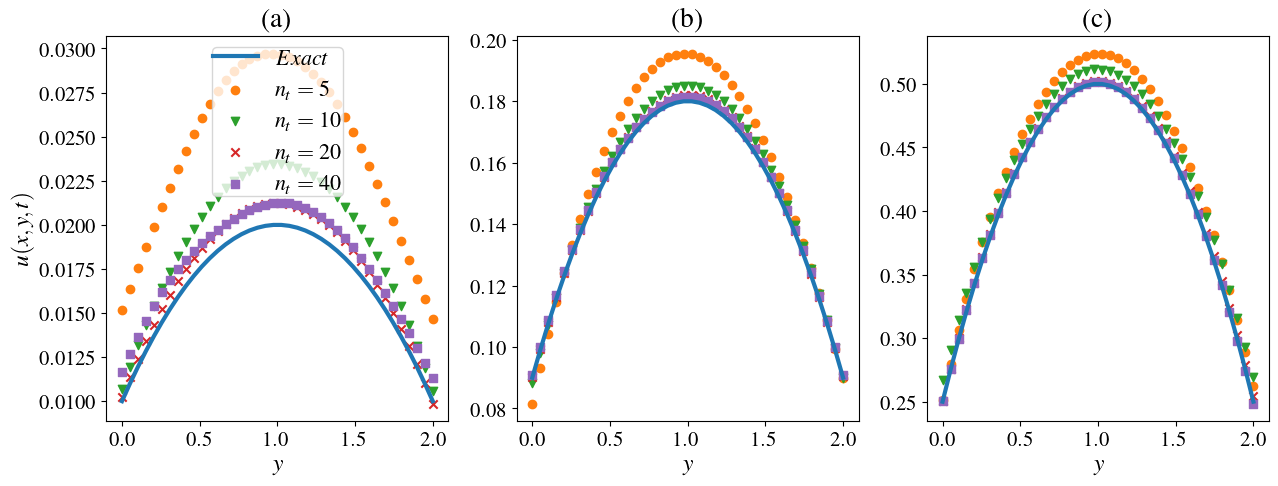

In [7]:
time_step_cases = []
for cfg in TIME_STEP_SETS:
    m = load_model(cfg['weights'], TMAX_TIME_STEP)
    time_step_cases.append({'model': m, 'label': cfg['label']})

make_comparison_figure(time_step_cases, TMAX_TIME_STEP,
                       save_as='time_step_study.png')

## 7. Effect of Spatial-Grid Density

Fixed `NT = 5`, varying `NX = NY ∈ {5, 10, 20}`.
Weight paths are set in Section 1 under `SPATIAL_SETS`.

Saved: spatial_grid_study.png


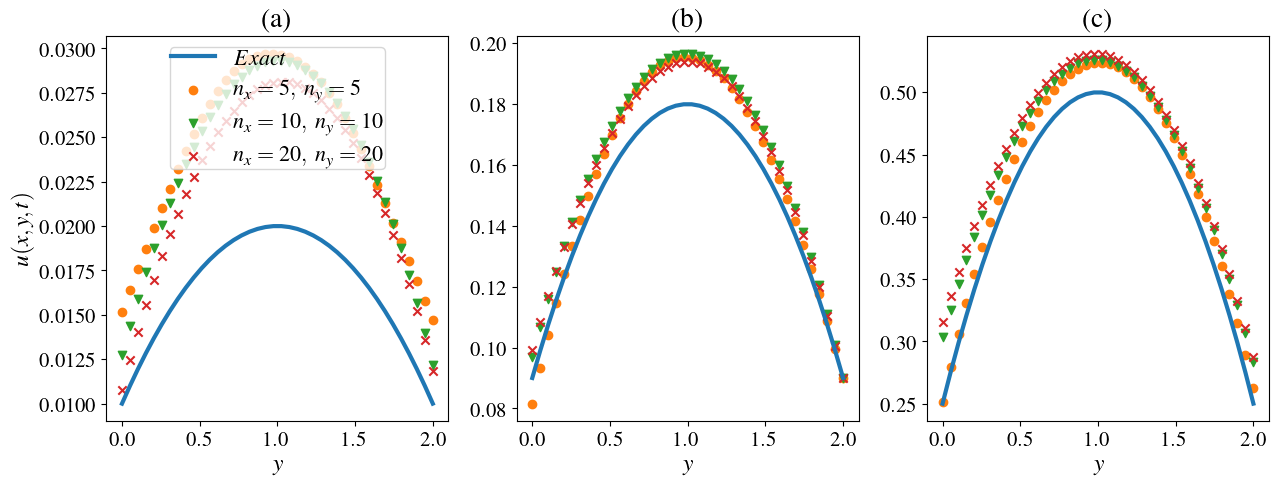

In [8]:
spatial_cases = []
for cfg in SPATIAL_SETS:
    m = load_model(cfg['weights'], TMAX_SPATIAL)
    spatial_cases.append({'model': m, 'label': cfg['label']})

make_comparison_figure(spatial_cases, TMAX_SPATIAL,
                       save_as='spatial_grid_study.png')

## 8. Diethelm vs L1 Comparison

Compare predictions from the two fractional discretizations at `TIME_SNAPSHOTS`.
Weight paths are set in Section 1 as `WEIGHTS_CAPUTO` and `WEIGHTS_L1`.

Saved: diethelm_vs_l1.png


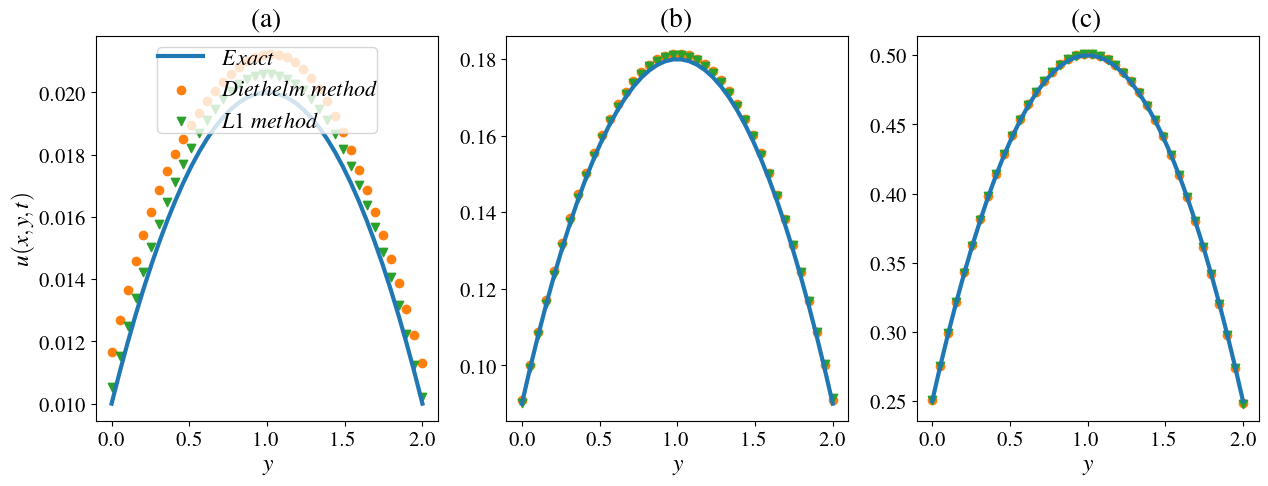

In [9]:
model_caputo = load_model(WEIGHTS_CAPUTO, TMAX_METHOD)
model_l1     = load_model(WEIGHTS_L1,     TMAX_METHOD)

method_cases = [
    {'model': model_caputo, 'label': r'$Diethelm\ method$'},
    {'model': model_l1,     'label': r'$L1\ method$'},
]

make_comparison_figure(method_cases, TMAX_METHOD,
                       save_as='diethelm_vs_l1.png')

## 9. Effect of Time Window

Compare `TMAX = 0.5` vs `TMAX = 1.0` at `TIME_SNAPSHOTS`.
Weight paths are set in Section 1 as `TMAX_05_WEIGHTS` and `TMAX_10_WEIGHTS`.

Saved: time_window_study.png


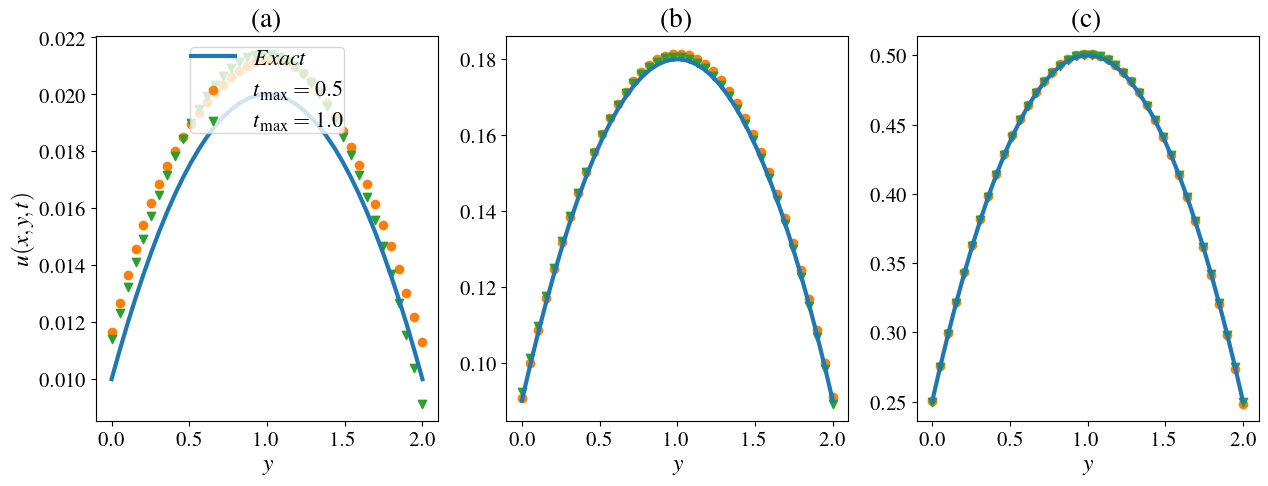

In [10]:
model_t05 = load_model(TMAX_05_WEIGHTS, TMAX_05)
model_t10 = load_model(TMAX_10_WEIGHTS, TMAX_10)

tmax_cases = [
    {'model': model_t05, 'label': r'$t_{\max} = 0.5$'},
    {'model': model_t10, 'label': r'$t_{\max} = 1.0$'},
]

make_comparison_figure(tmax_cases, TMAX_10,
                       save_as='time_window_study.png')

## 10. Effect of Network Size

Compare four architectures: 2L×10N, 3L×10N, 4L×20N, 7L×40N.
Weight paths and architecture specs are set in Section 1 under `NETWORK_SETS`.

Saved: network_size_study.png


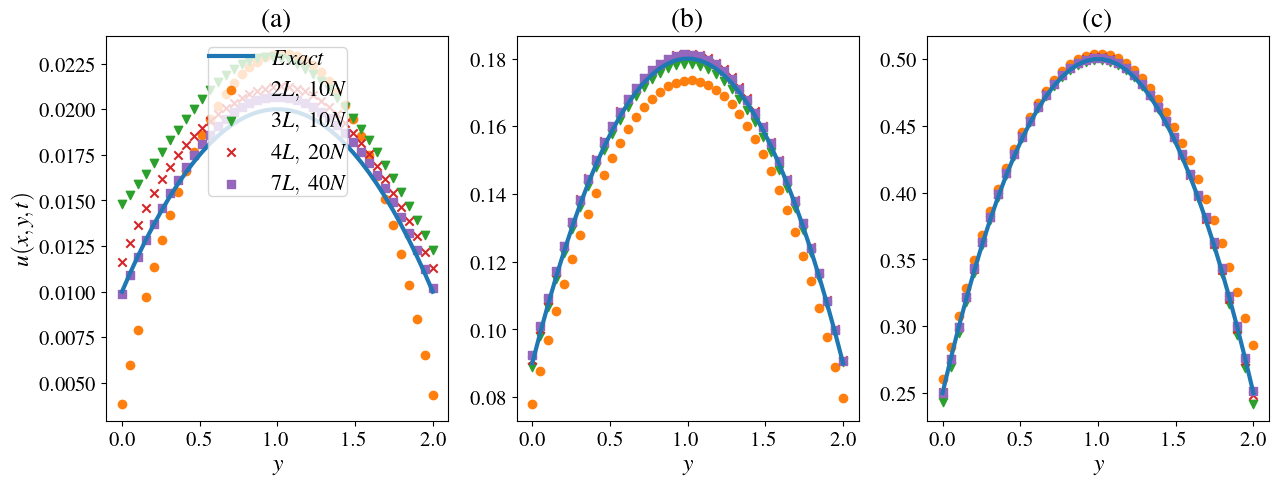

In [11]:
network_cases = []
for cfg in NETWORK_SETS:
    m = load_model(cfg['weights'], cfg['tmax'],
                   num_layers=cfg['layers'], num_neurons=cfg['neurons'])
    network_cases.append({'model': m, 'label': cfg['label']})

make_comparison_figure(network_cases, NETWORK_SETS[0]['tmax'],
                       save_as='network_size_study.png')

## 11. 3D Scatter Comparison — Exact, Diethelm, L1

Three-panel 3D scatter plot over the full (x, y, t) volume.

In [12]:
# Build evaluation grid
pts   = list(product(np.linspace(XMIN, XMAX, N_EVAL_3D),
                     np.linspace(YMIN, YMAX, N_EVAL_3D),
                     np.linspace(TMIN, TMAX_3D, N_EVAL_3D)))
X_3d  = tf.convert_to_tensor(pts, dtype=DTYPE)
X_np  = np.array(pts)
X_arr, Y_arr, T_arr = X_np[:, 0], X_np[:, 1], X_np[:, 2]

# Load models and run predictions
model_3d_cap = load_model(WEIGHTS_3D_CAPUTO, TMAX_3D)
model_3d_l1  = load_model(WEIGHTS_3D_L1,     TMAX_3D)

u_exact_3d = exact_solution(X_arr, Y_arr, T_arr)
u_cap_3d   = model_3d_cap.predict(X_3d, verbose=0).flatten()
u_l1_3d    = model_3d_l1.predict(X_3d,  verbose=0).flatten()

print(f'MSE Caputo : {np.mean(np.square(u_cap_3d - u_exact_3d)):.4e}')
print(f'MSE L1     : {np.mean(np.square(u_l1_3d  - u_exact_3d)):.4e}')

2026-04-22 20:36:11.511038: W tensorflow/core/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


MSE Caputo : 1.5423e-06
MSE L1     : 5.5465e-07


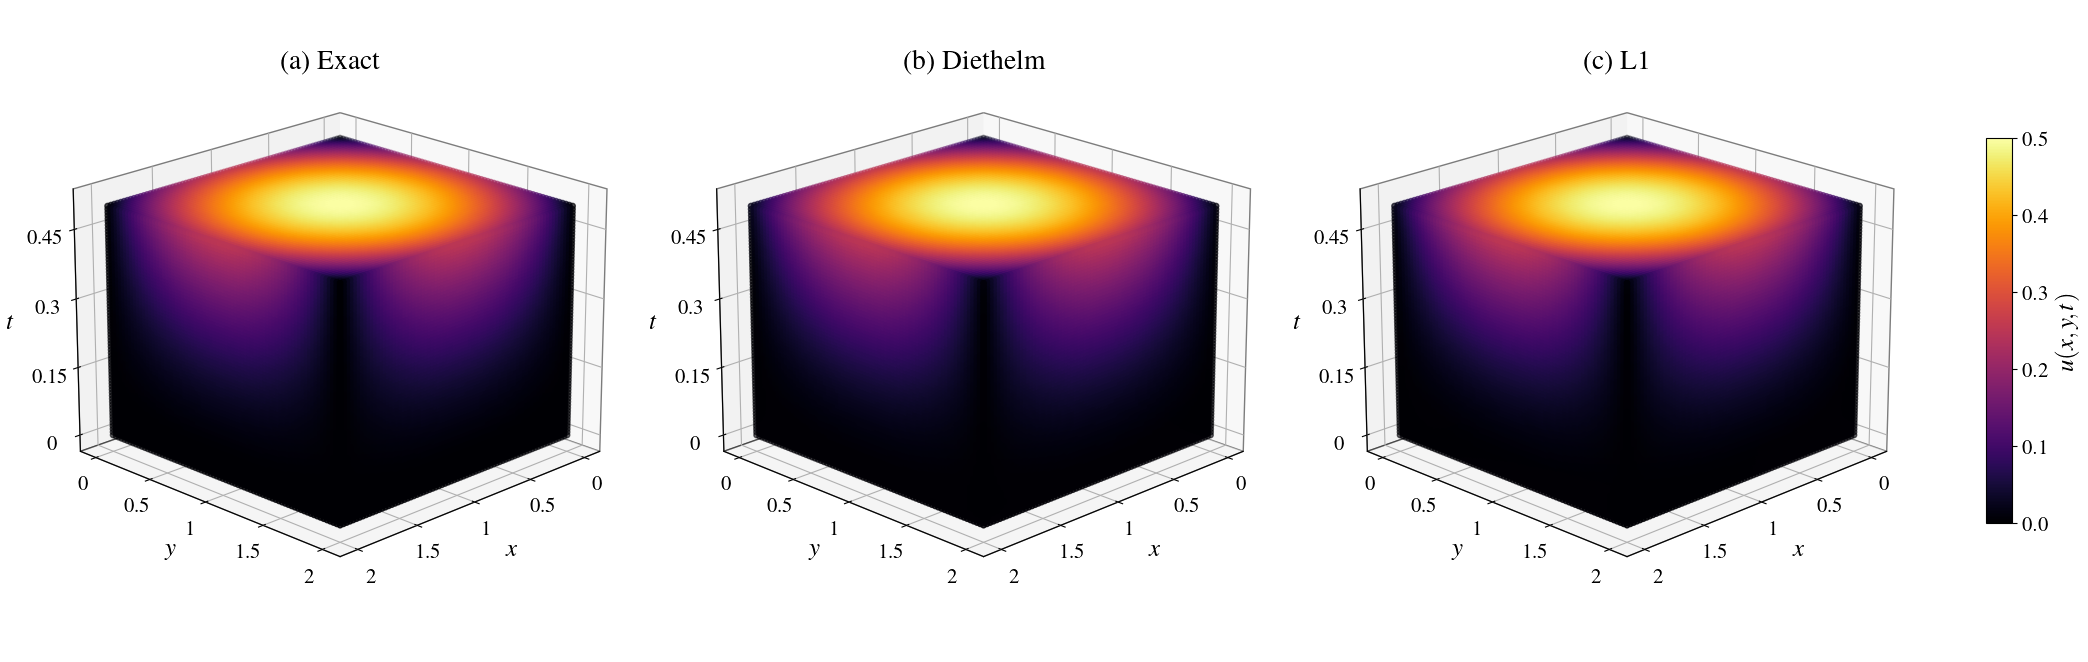

In [13]:
def fmt(v, _):
    return f'{v:g}'

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(30, 10), dpi=100,
                                     subplot_kw={'projection': '3d'})

img1 = ax1.scatter(X_arr, Y_arr, T_arr, c=u_exact_3d, cmap='inferno', s=15)
img2 = ax2.scatter(X_arr, Y_arr, T_arr, c=u_cap_3d,   cmap='inferno', s=15)
img3 = ax3.scatter(X_arr, Y_arr, T_arr, c=u_l1_3d,    cmap='inferno', s=15)

for ax, title in zip([ax1, ax2, ax3], ['(a) Exact', '(b) Diethelm', '(c) L1']):
    ax.set_xlabel('$x$', labelpad=10, fontsize=18)
    ax.set_ylabel('$y$', labelpad=10, fontsize=18)
    ax.set_zlabel('$t$', labelpad=10, fontsize=18, rotation=0)
    ax.view_init(elev=20, azim=45)
    ax.set_title(title, y=0.97)
    for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
        axis.set_major_formatter(FuncFormatter(fmt))
        axis.set_major_locator(MaxNLocator(5))
    for pane in [ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane]:
        pane.set_edgecolor('k')
    ax.tick_params(axis='z', pad=5)
    ax.set_box_aspect(aspect=None, zoom=0.9)

fig.subplots_adjust(wspace=0.001)
cbar = fig.colorbar(img1, ax=[ax1, ax2, ax3], shrink=0.5, pad=0.02, aspect=15)
cbar.set_label('$u(x,y,t)$', fontsize=18)
plt.savefig('3D_scatter_exact_cap_l1.png', dpi=300, transparent=False, bbox_inches='tight')
plt.show()

## 12. Quantitative Evaluation

Computes L2 relative error and L∞ absolute error for each saved configuration
defined in `EVAL_CASES` (Section 1) — **no re-training required**.
Produces a summary table and error-vs-runtime log-log curves.

In [14]:
results = []
for (label, tmax, nx, ny, nt, runtime_min, iters, w_path) in EVAL_CASES:
    m = load_model(w_path, tmax)
    l2, linf = compute_error_metrics(m, tmax)
    results.append({
        'Case':            label,
        'NX': nx, 'NY': ny, 'NT': nt,
        'TMAX':            tmax,
        'Runtime (min)':   runtime_min,
        'Iterations':      iters,
        'L2 rel error':    l2,
        'L-inf abs error': linf,
    })
    print(f'{label}: L2={l2:.4e}  L∞={linf:.4e}  ({runtime_min} min)')

5×5×5  Caputo 30min: L2=1.0375e-01  L∞=9.1941e-02  (30 min)
10×10×10 Caputo 30min: L2=3.8623e-02  L∞=4.7814e-02  (30 min)
5×5×40 Caputo 30min: L2=8.7706e-03  L∞=2.0356e-02  (30 min)
5×5×40 L1 30min: L2=5.6892e-03  L∞=1.6749e-02  (30 min)


In [15]:
# ---- Summary table -------------------------------------------------------
df = pd.DataFrame(results)
df.to_csv('quantitative_metrics_3D.csv', index=False)
print(df[['Case', 'Runtime (min)', 'L2 rel error', 'L-inf abs error']].to_string(
    index=False,
    formatters={'L2 rel error':    '{:.3e}'.format,
                'L-inf abs error': '{:.3e}'.format}))

                 Case  Runtime (min) L2 rel error L-inf abs error
  5×5×5  Caputo 30min             30    1.038e-01       9.194e-02
10×10×10 Caputo 30min             30    3.862e-02       4.781e-02
  5×5×40 Caputo 30min             30    8.771e-03       2.036e-02
      5×5×40 L1 30min             30    5.689e-03       1.675e-02


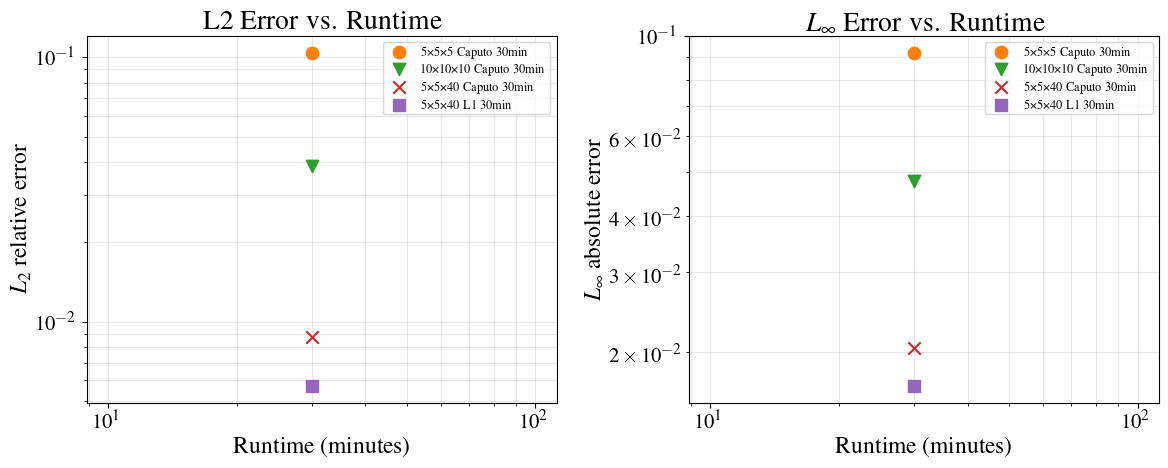

In [16]:
# ---- Error vs runtime log-log curves ------------------------------------
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

runtimes  = [r['Runtime (min)']   for r in results]
l2_errs   = [r['L2 rel error']    for r in results]
linf_errs = [r['L-inf abs error'] for r in results]
labels    = [r['Case']            for r in results]

for i, (rt, l2, li, lbl) in enumerate(zip(runtimes, l2_errs, linf_errs, labels)):
    axs[0].scatter(rt, l2,  marker=MARKERS[i], color=COLORS[i+1], s=80, label=lbl, zorder=3)
    axs[1].scatter(rt, li, marker=MARKERS[i], color=COLORS[i+1], s=80, label=lbl, zorder=3)

for ax, ylabel, title in zip(
    axs,
    [r'$L_2$ relative error', r'$L_\infty$ absolute error'],
    ['L2 Error vs. Runtime', r'$L_\infty$ Error vs. Runtime'],
):
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Runtime (minutes)')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, which='both', alpha=0.3)
    ax.legend(fontsize=9, borderpad=0.3)

plt.tight_layout()
plt.savefig('error_scans_3D.png', dpi=300, bbox_inches='tight')
plt.show()